# Deconvolved Data Replication Timing from 10k MNase-seq Windows

April 24, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

This will require a tuning of the alpha parameter.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.976


In [90]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()


In [95]:
mnase_analysis_rep2.compute_replication_timing()

In [97]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

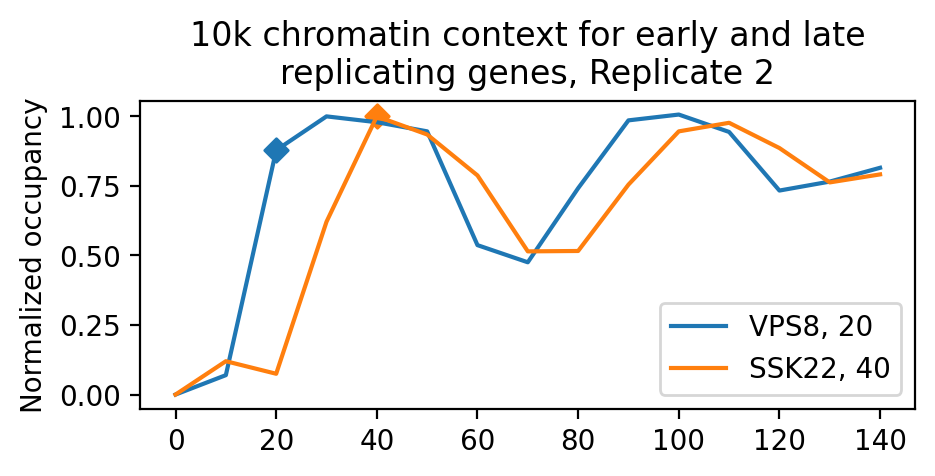

In [98]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [99]:
from src.deconv_replication_timing import DeconvReplicationProfileAnalysis

deconv_rep_analysis1 = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)
deconv_rep_analysis2 = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)

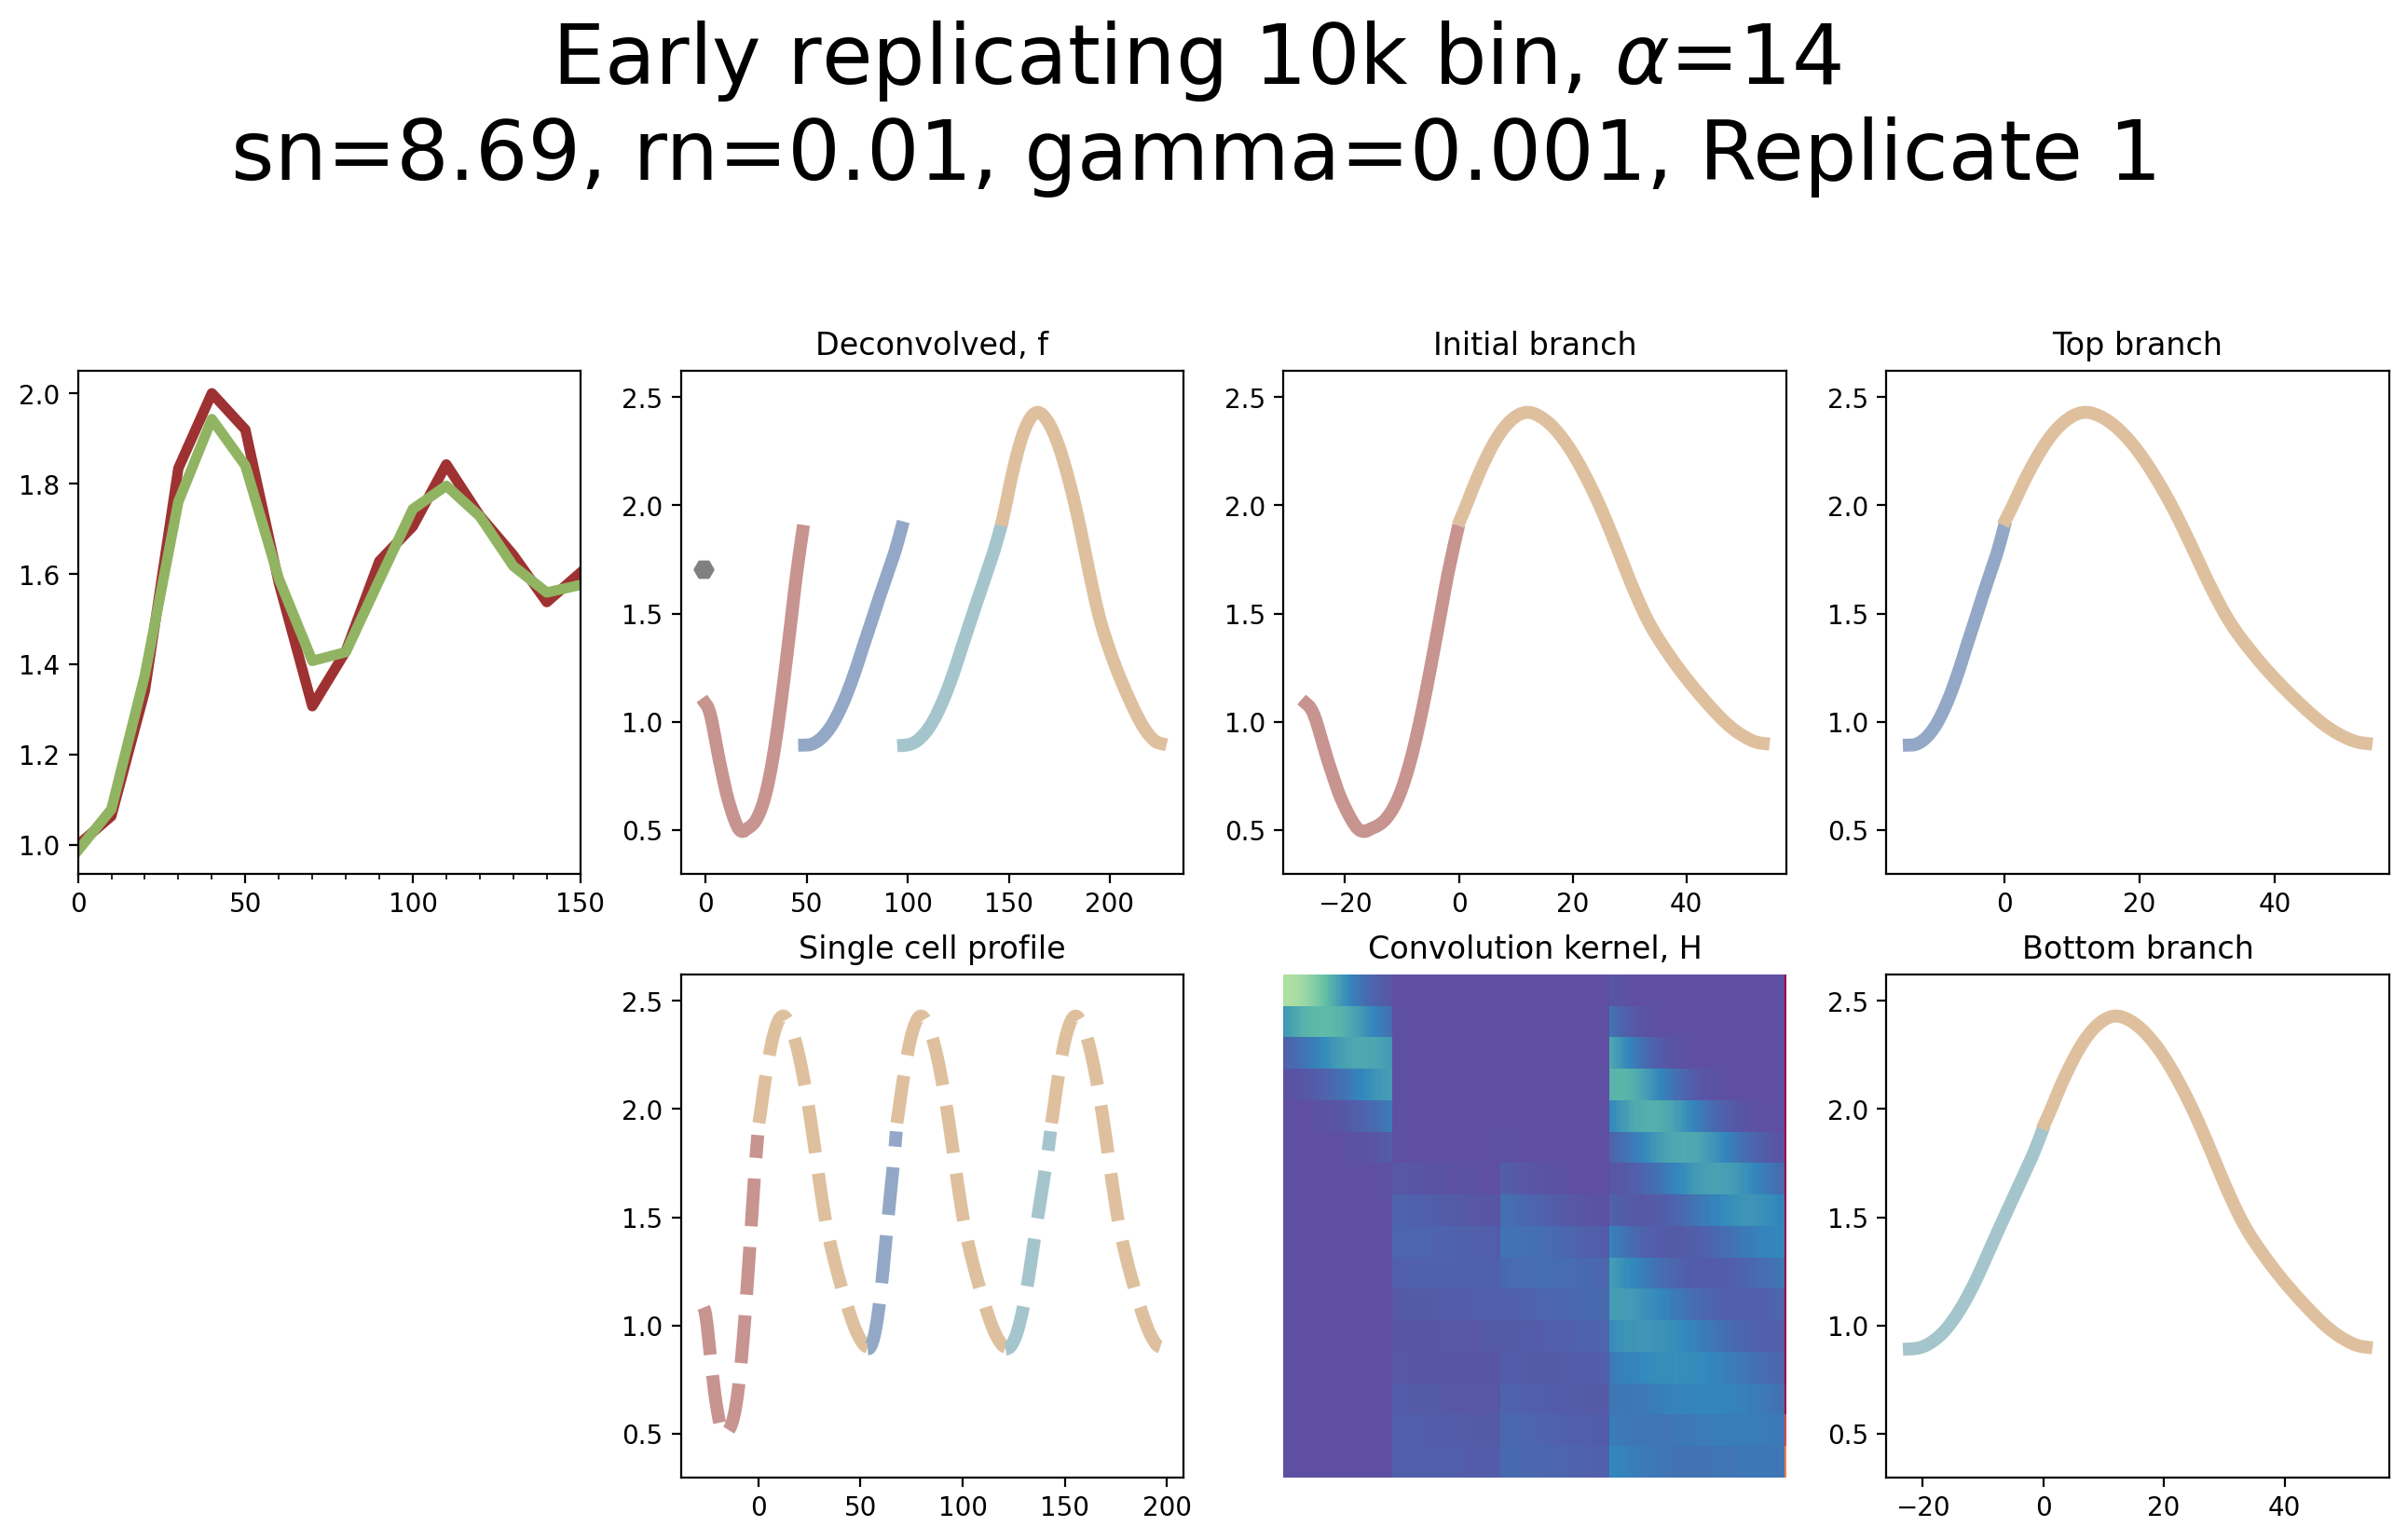

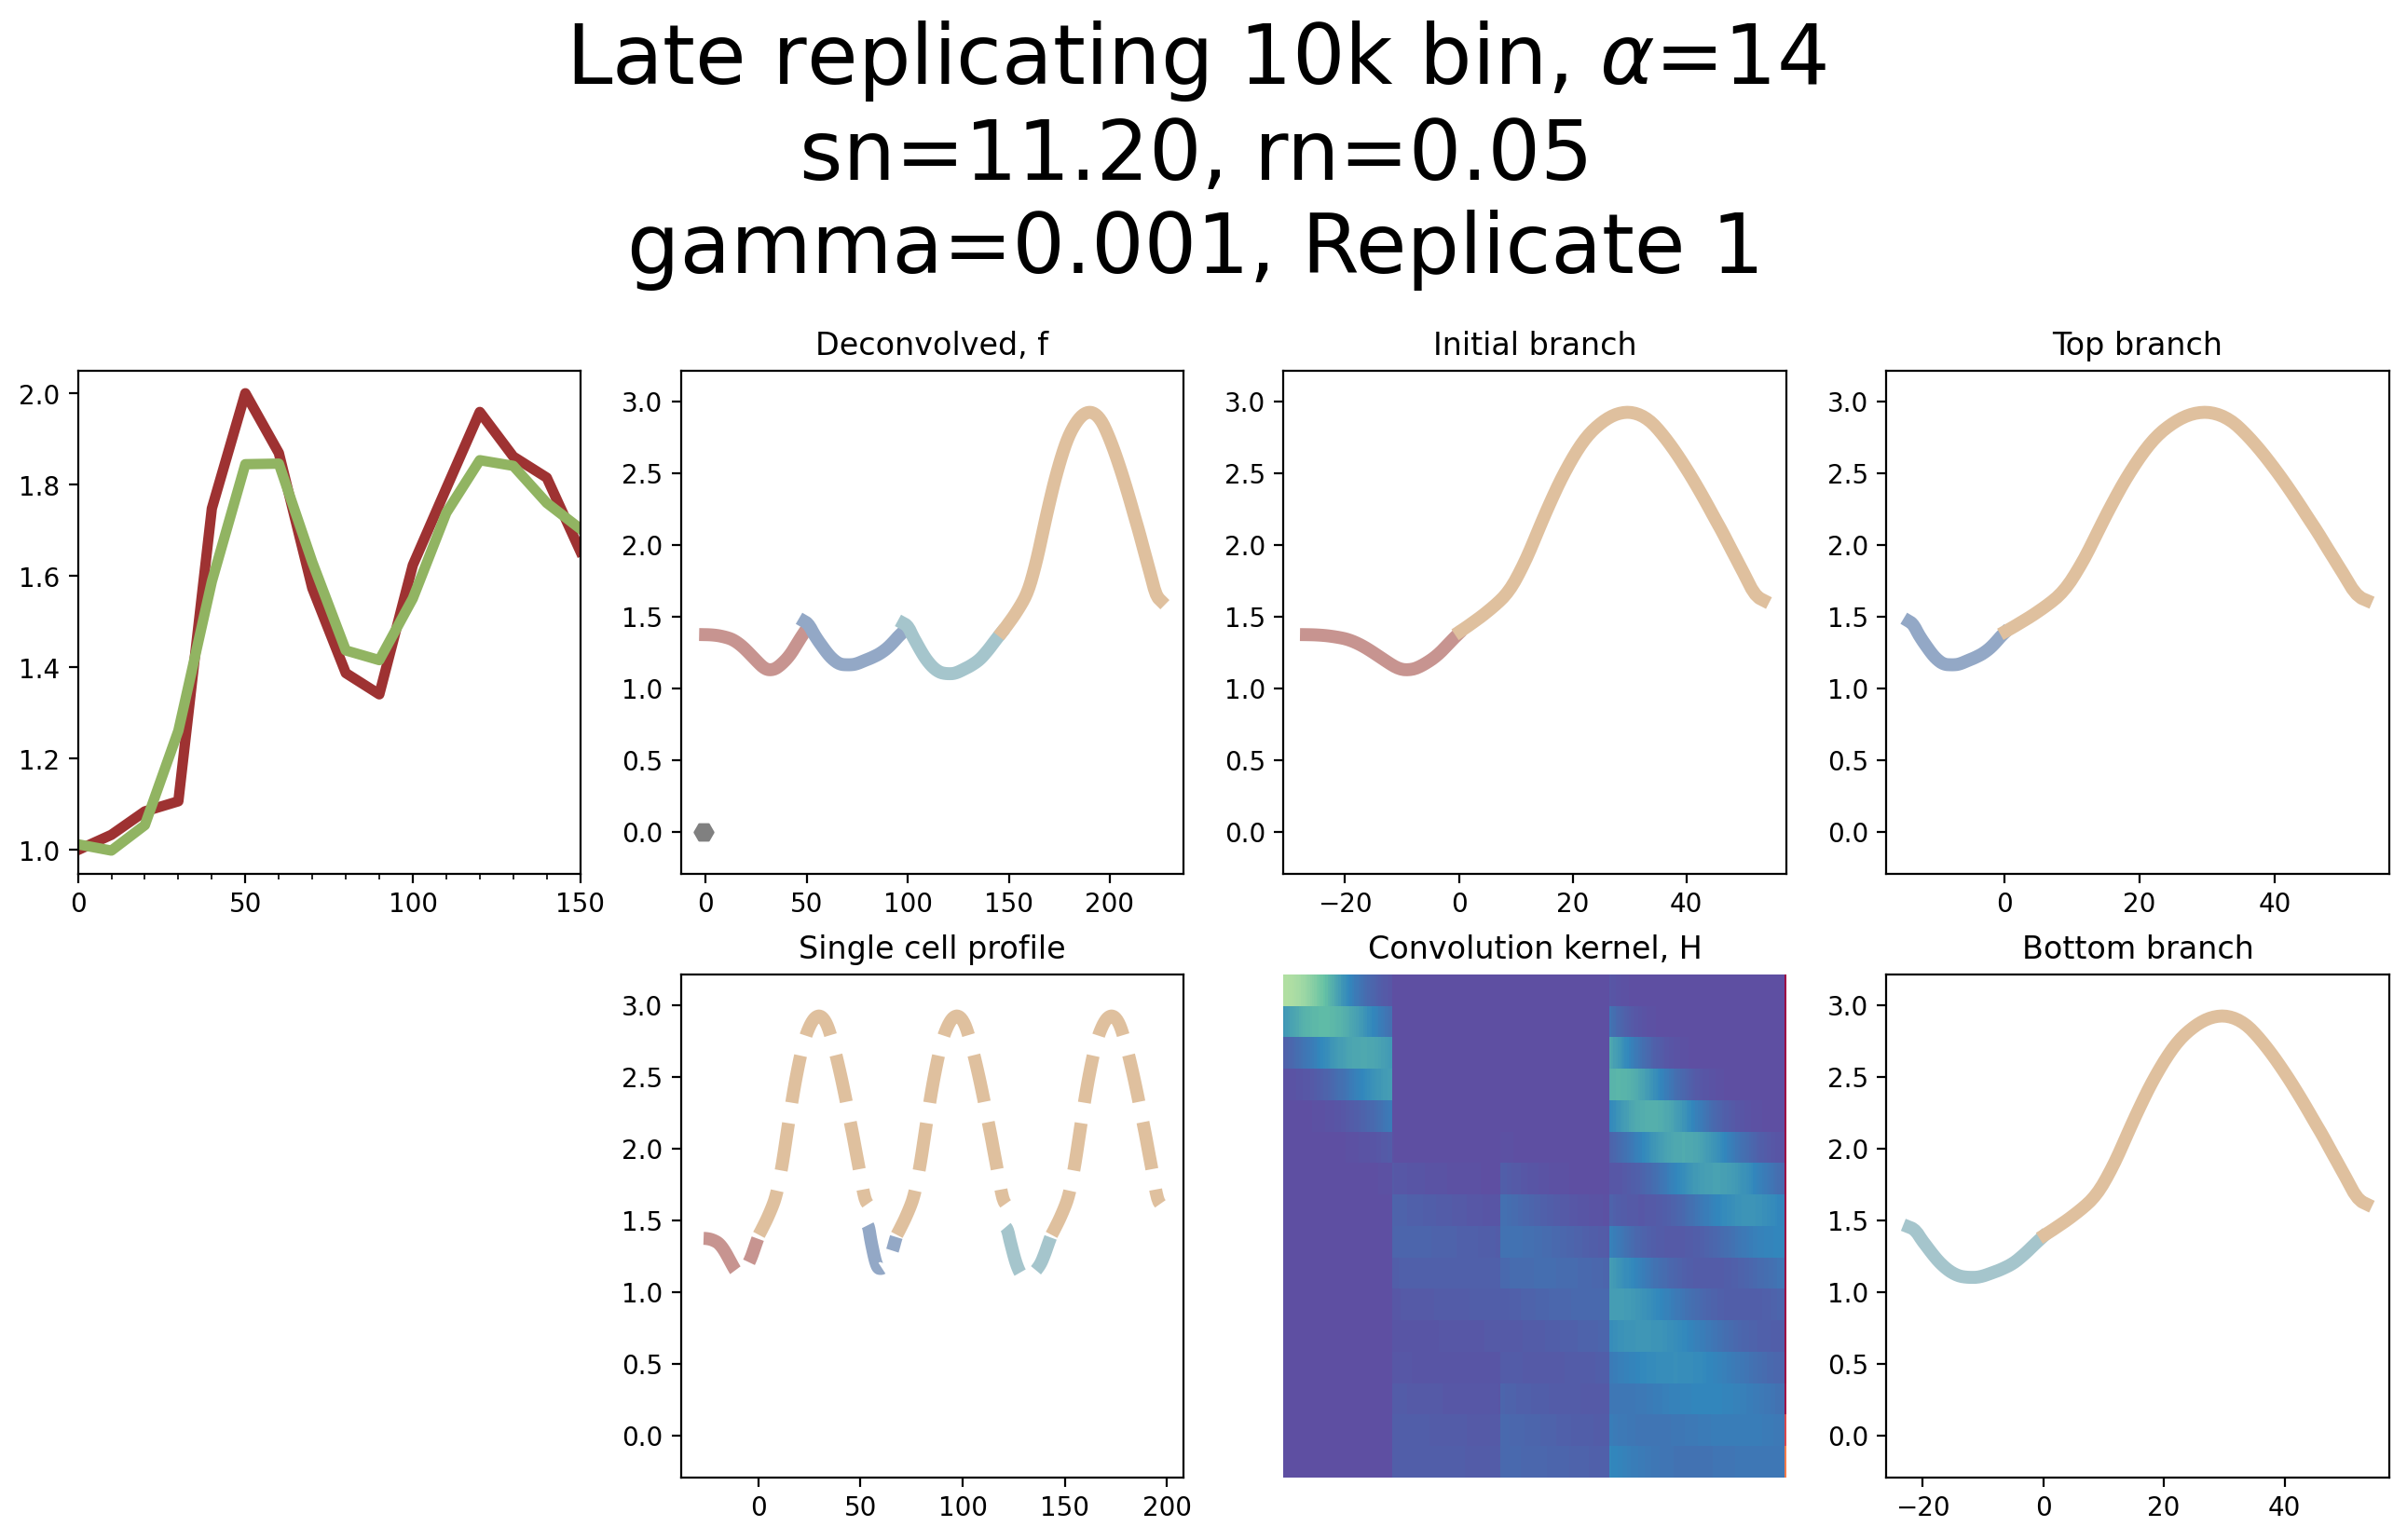

In [57]:
deconv_rep_analysis1.compare_early_late_deconv_bin_curves(14, 1)

In [102]:
deconv_rep_analysis1.create_chr_bin_curves(1, 4)
deconv_rep_analysis2.create_chr_bin_curves(2, 4)

Setting up bin curves for replicate 1, chromosome 4
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 4
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.


In [140]:
deconv_rep_analysis1.alpha_search(alphas=np.arange(0, 32, 1))

0/32, alpha=0
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:53.430
The fitting norm is 0.11, the smoothing norm is: 19.47
00:01:53.976
1/32, alpha=1
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:45.976
The fitting norm is 0.13, the smoothing norm is: 18.00
00:03:40.602
2/32, alpha=2
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:02:07.190
The fitting norm is 0.13, the smoothing norm is: 17.63
00:05:48.625
3/32, alpha=3
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:02:00.131
The fitting norm is 0.11, the smoothing norm is: 18.02
00:07:49.360
4/32, alpha=4
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:56.727
The fitting norm is 0.12, the smoothing norm is: 17.00
00:09:46.708
5/32, alpha=5
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:02:00.587
The fitting norm is 0.12, the smoothing norm is: 16.73
00:11:47.890
6/32, alpha=6
Deconvolving with gamma=0.001, gamma_prime=0

In [141]:
deconv_rep_analysis2.alpha_search(alphas=np.arange(0, 32, 1))

0/32, alpha=0
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:34:09.856
The fitting norm is 0.11, the smoothing norm is: 18.39
00:34:10.493
1/32, alpha=1
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 03:52:06.595
The fitting norm is 0.12, the smoothing norm is: 18.18
04:26:17.694
2/32, alpha=2
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:51.123
The fitting norm is 0.11, the smoothing norm is: 17.85
04:28:09.422
3/32, alpha=3
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:44.209
The fitting norm is 0.12, the smoothing norm is: 17.66
04:29:54.190
4/32, alpha=4
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:47.947
The fitting norm is 0.11, the smoothing norm is: 17.24
04:31:42.736
5/32, alpha=5
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:48.717
The fitting norm is 0.10, the smoothing norm is: 16.96
04:33:32.059
6/32, alpha=6
Deconvolving with gamma=0.001, gamma_prime=0

In [142]:
pd.DataFrame(deconv_rep_analysis1.alphas).to_csv("output/alpha_search_mnase/rep1_alpha.csv")
pd.DataFrame(deconv_rep_analysis2.alphas).to_csv("output/alpha_search_mnase/rep2_alpha.csv")

In [143]:
np.save("output/alpha_search_mnase/rep1_alpha_fs.npy", deconv_rep_analysis1.alpha_fs)
np.save("output/alpha_search_mnase/rep2_alpha_fs.npy", deconv_rep_analysis2.alpha_fs)

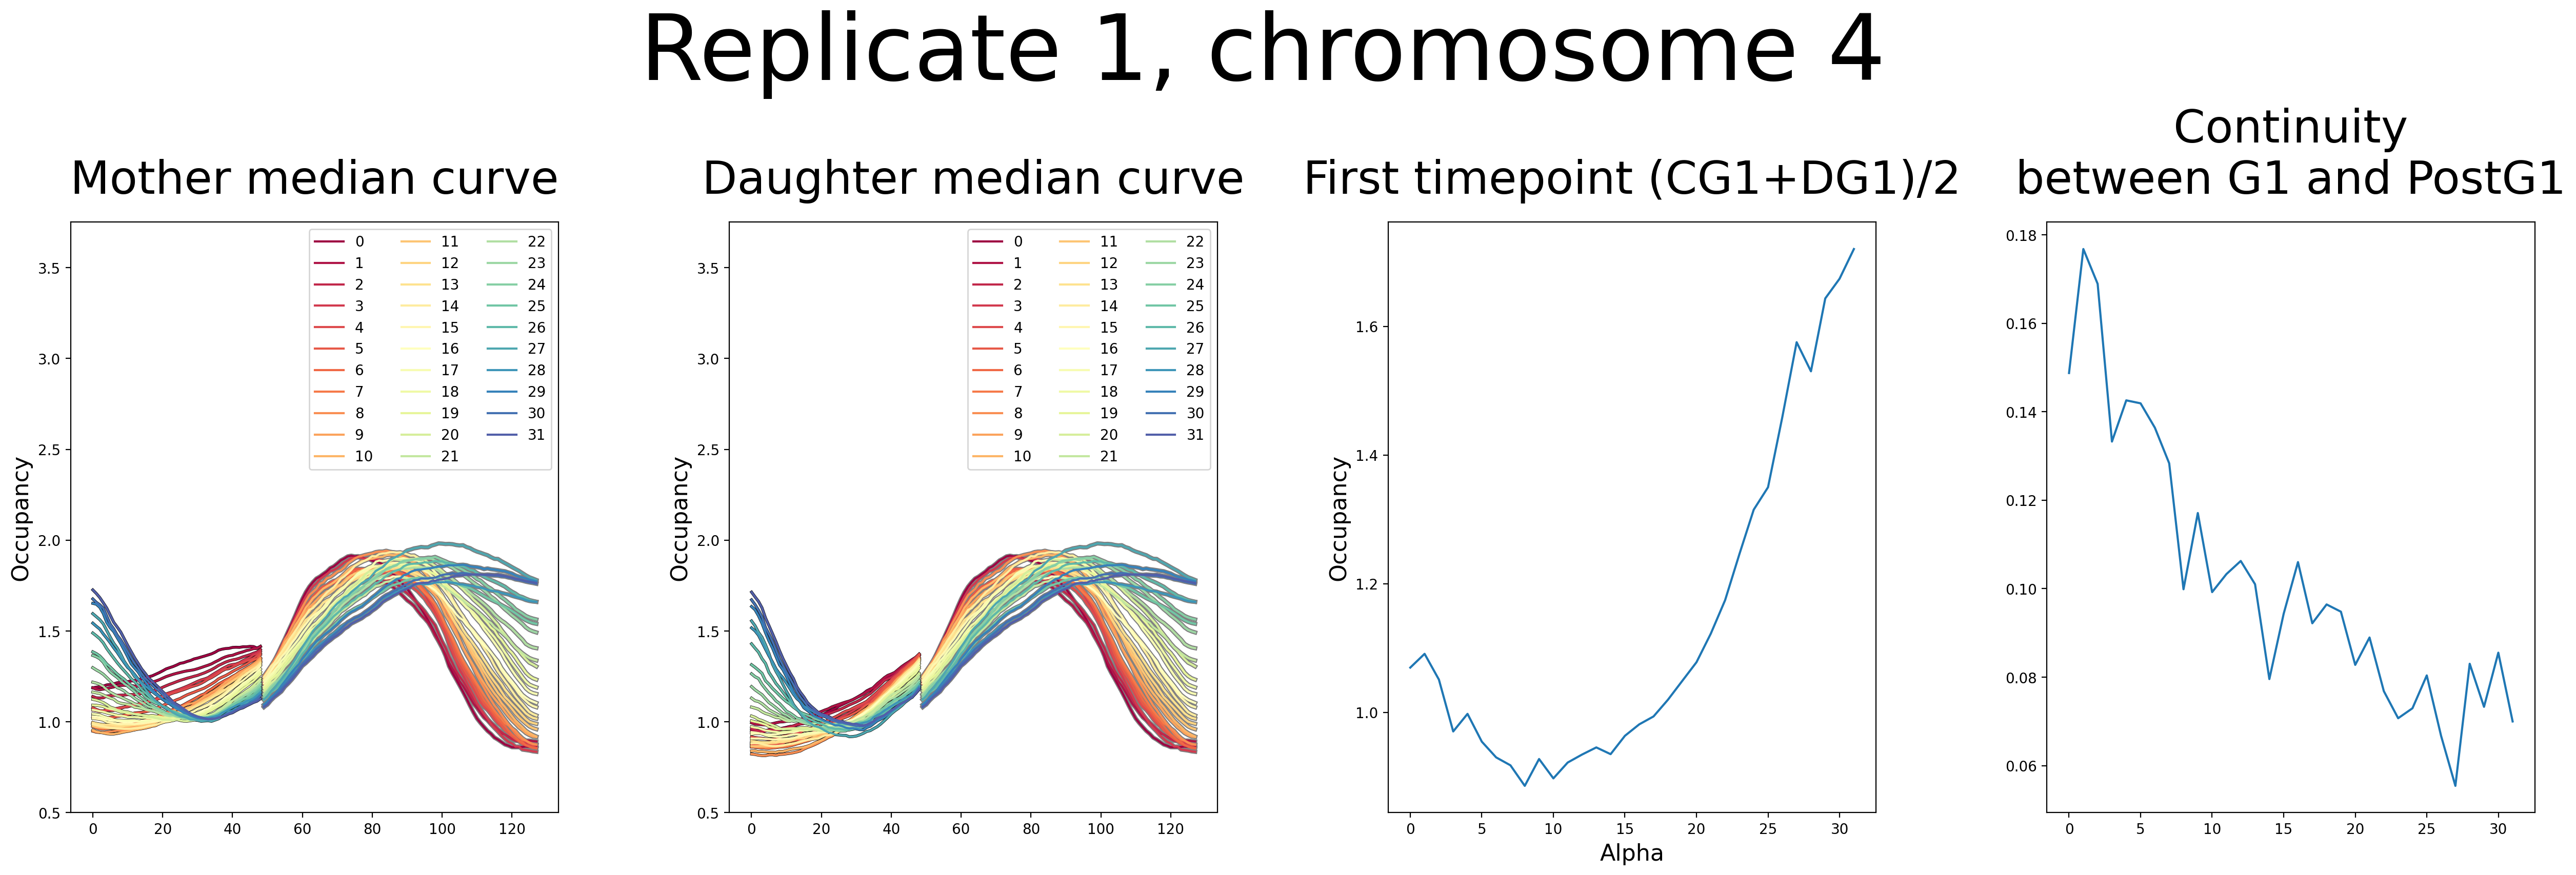

In [392]:
deconv_rep_analysis1.plot_alpha_search_results()

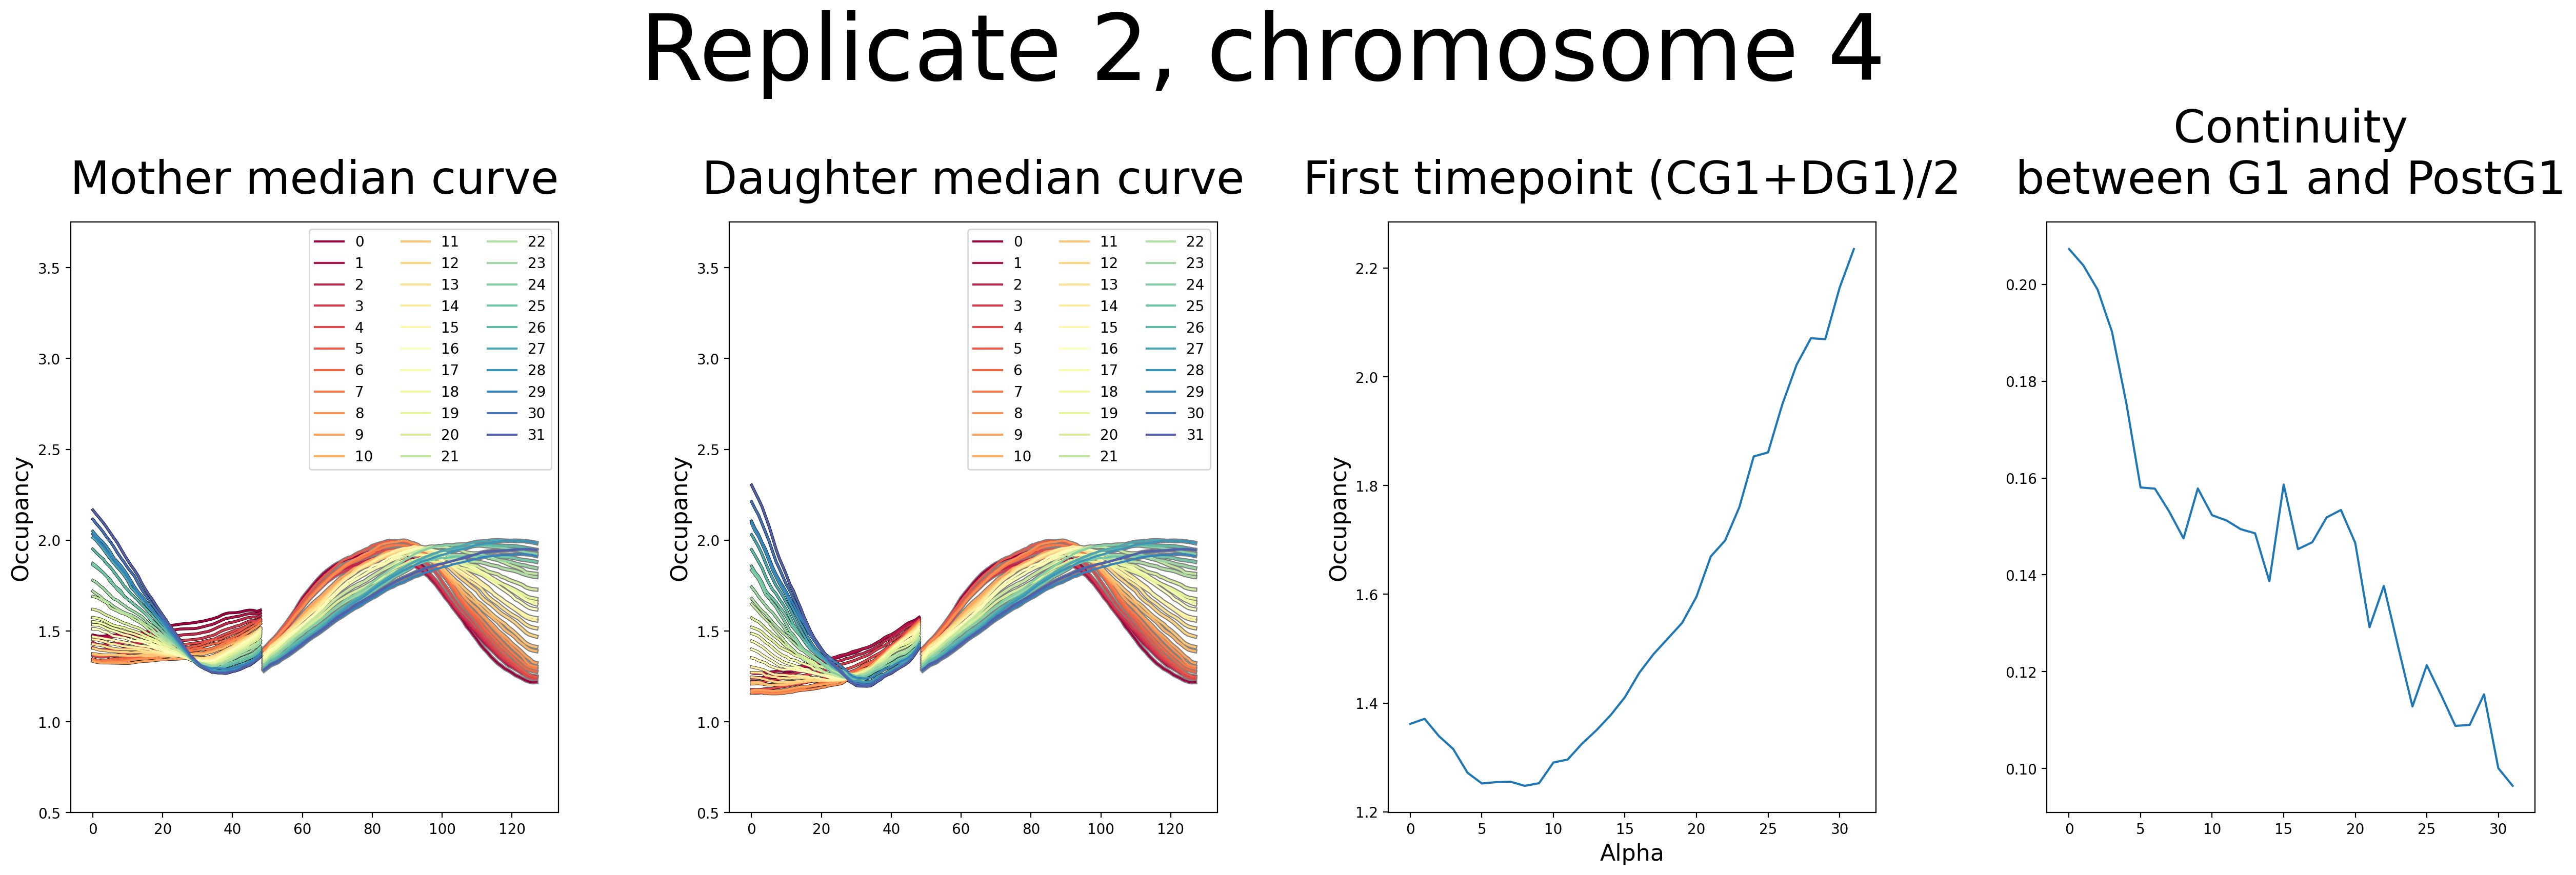

In [393]:
deconv_rep_analysis2.plot_alpha_search_results()

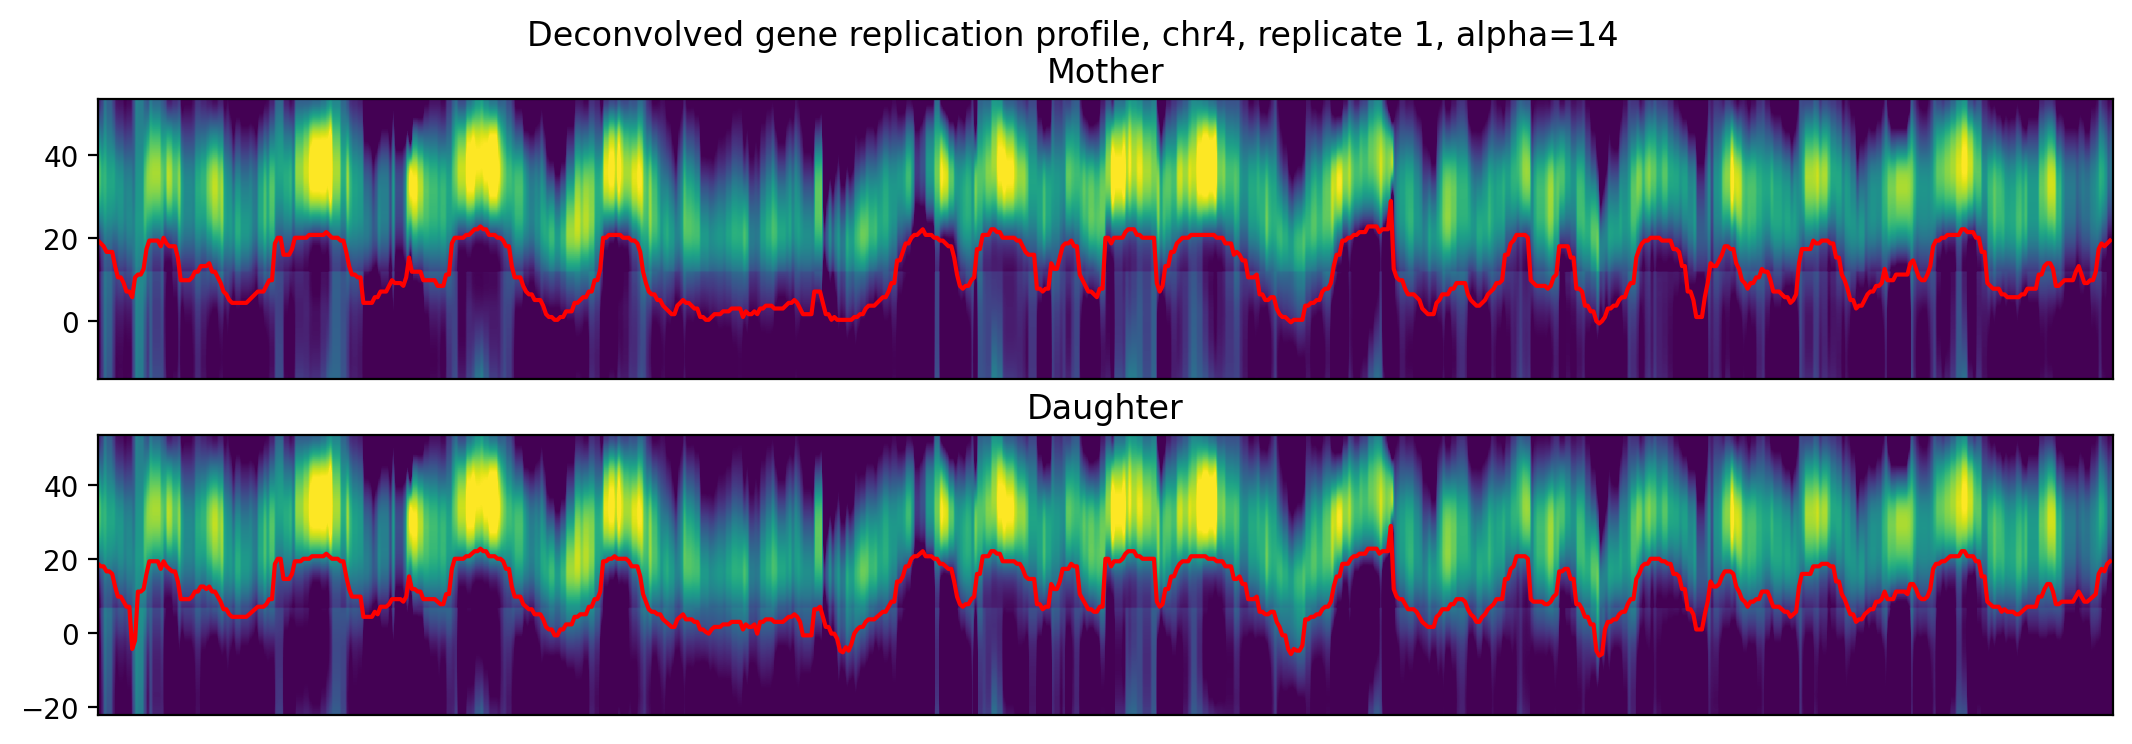

In [631]:
deconv_rep_analysis1.plot_example_alpha_repl_timing(14)

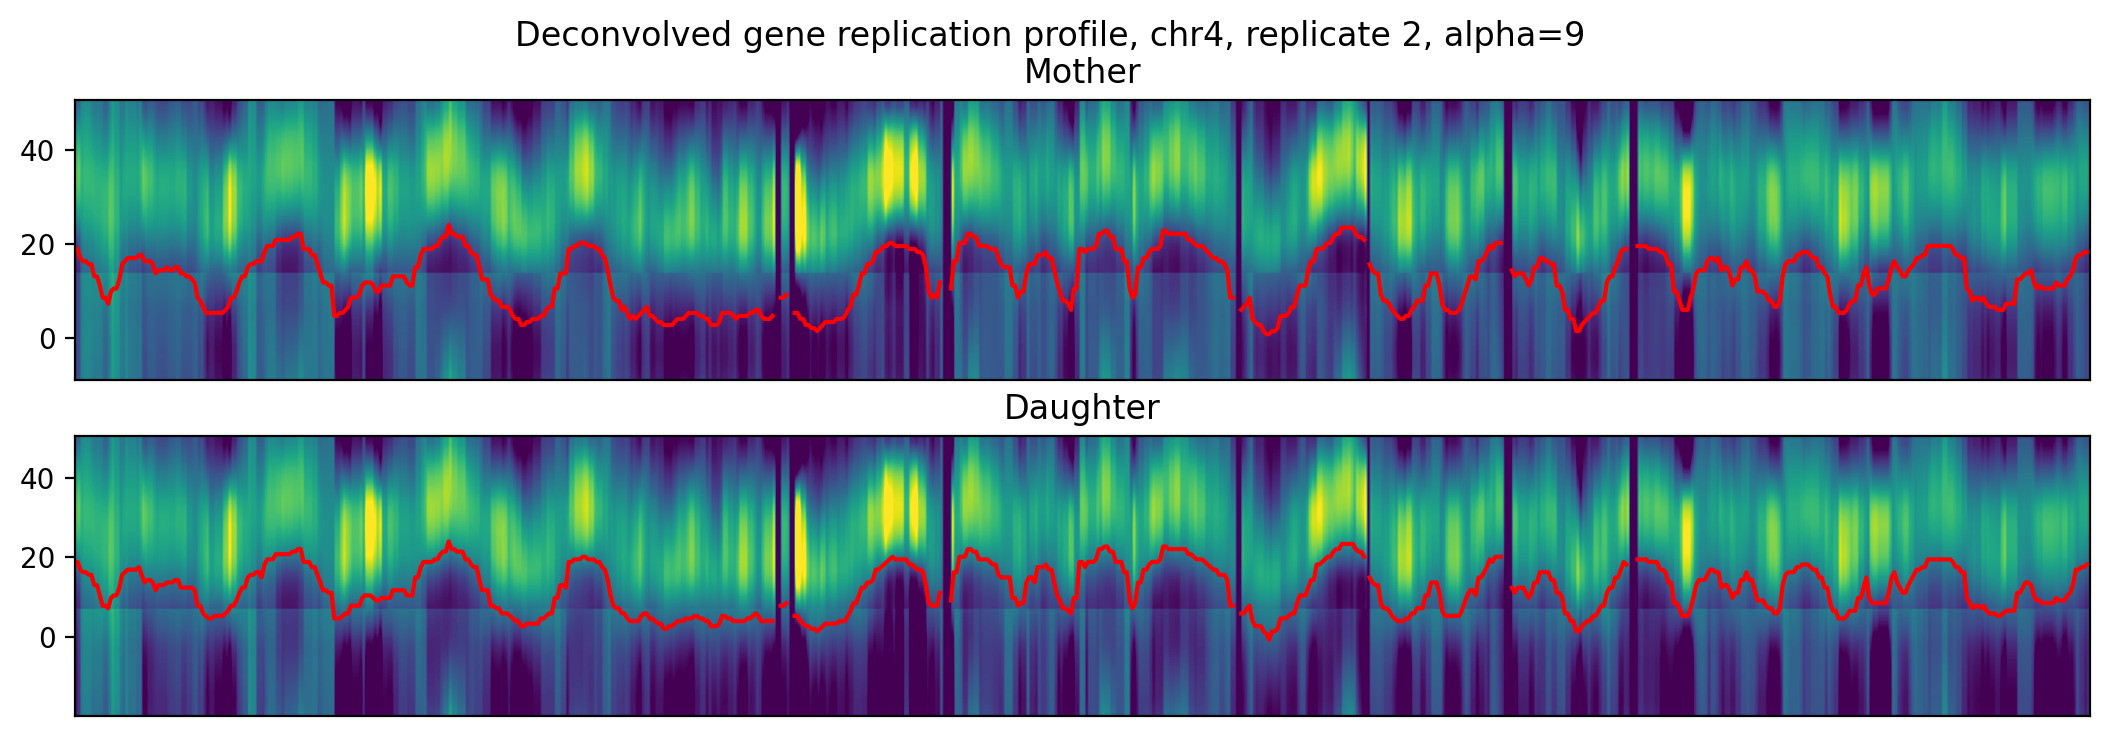

In [630]:
deconv_rep_analysis2.plot_example_alpha_repl_timing(9)

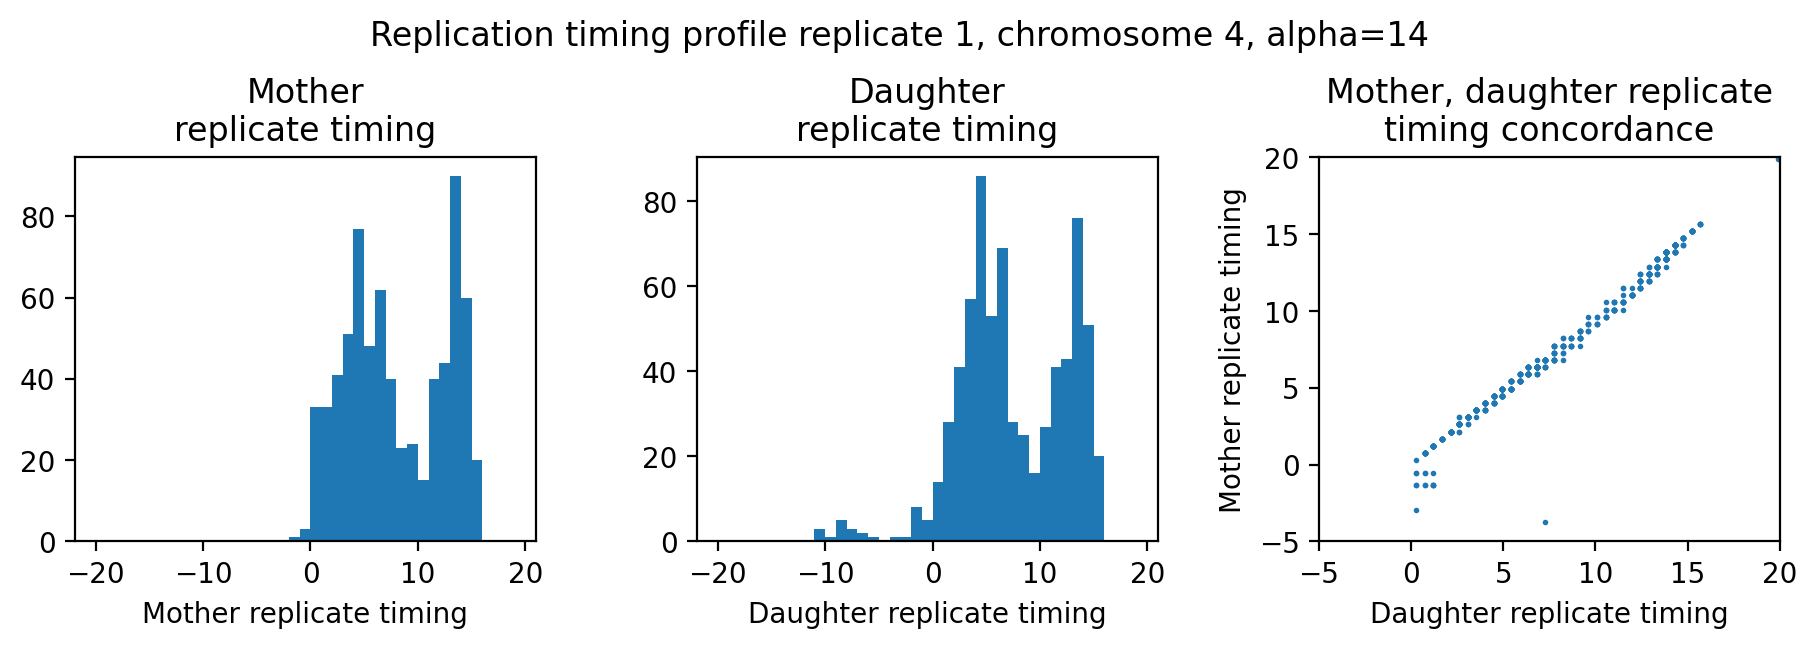

In [435]:
deconv_rep_analysis1.plot_replicate_timing_distribution()

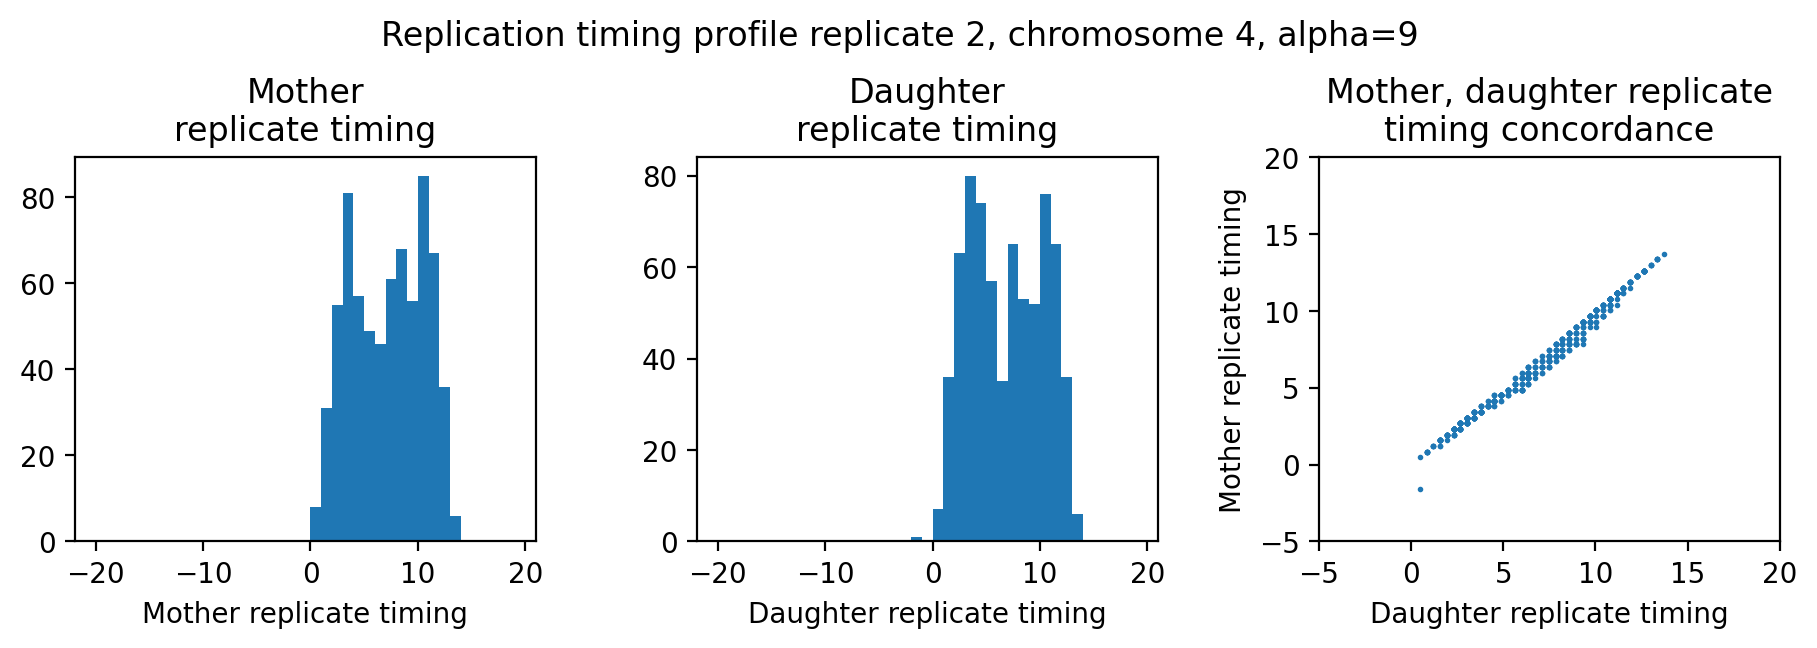

In [436]:
deconv_rep_analysis2.plot_replicate_timing_distribution()

In [791]:
from src.combined_deconv_replication_timing import CombinedDeconvReplicationProfileAnalysis

combined_repl_analysis = CombinedDeconvReplicationProfileAnalysis(deconv_rep_analysis1,
                                                                  deconv_rep_analysis2)

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


In [793]:
combined_repl_analysis.deconvolve_bin_curves()

Deconvolving combined model with gamma=0.001, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 706)
Deconvolved in : 00:02:25.458
The fitting norm is 0.18, the smoothing norm is: 16.46


In [796]:
combined_repl_analysis.compute_combined_replication_timing()

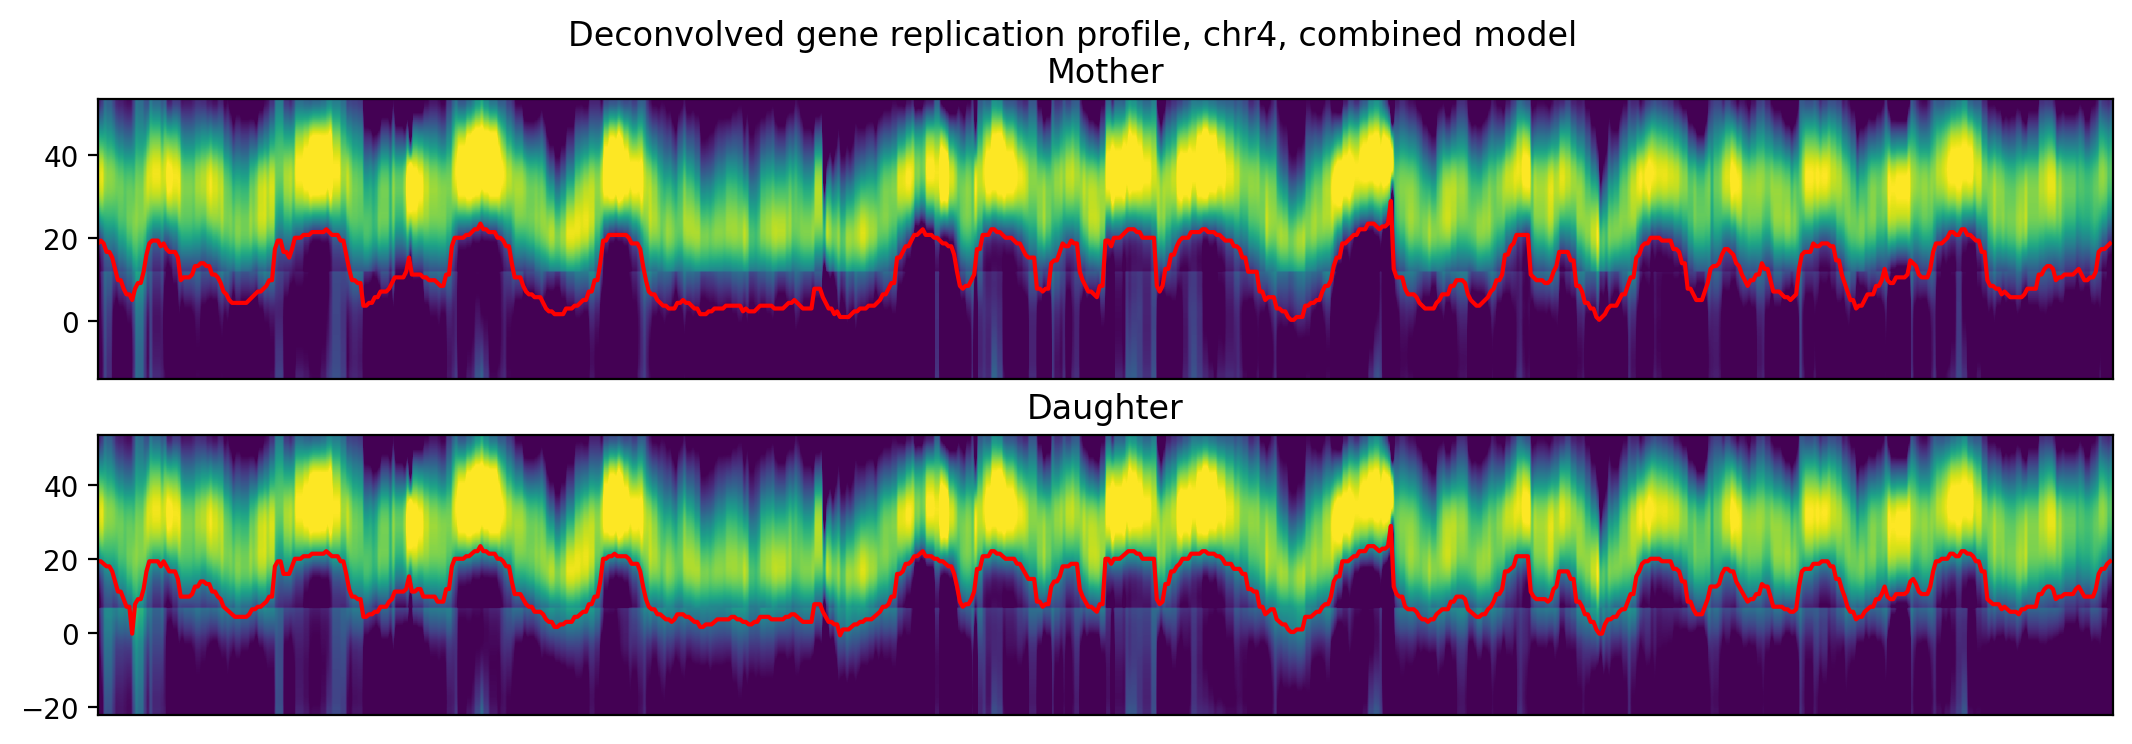

In [799]:
combined_repl_analysis.plot_replication_timing()

In [800]:
# Let's try chrom 10

In [801]:
combined_repl_analysis.set_chromosome(10)

Setting up bin curves for replicate 1, chromosome 10
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 10
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.


In [802]:
combined_repl_analysis.deconvolve_bin_curves()

Deconvolving combined model with gamma=0.001, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 334)
Deconvolved in : 00:00:59.379
The fitting norm is 0.20, the smoothing norm is: 17.46


In [858]:
combined_repl_analysis.compute_combined_replication_timing()

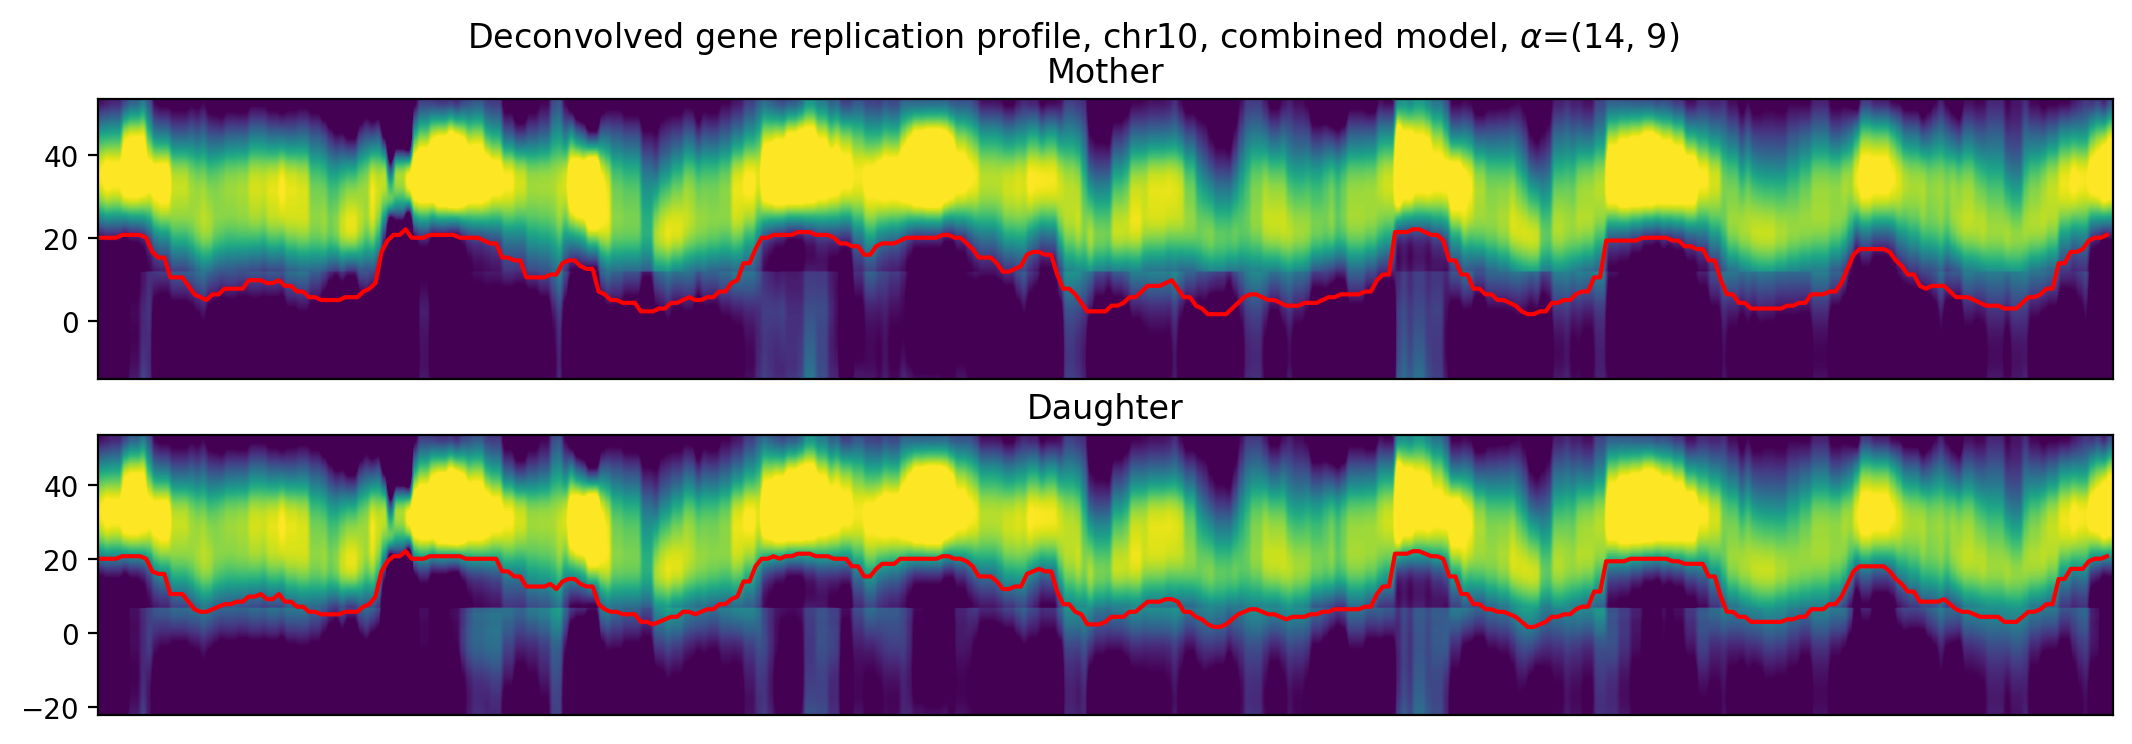

In [833]:
combined_repl_analysis.plot_replication_timing()

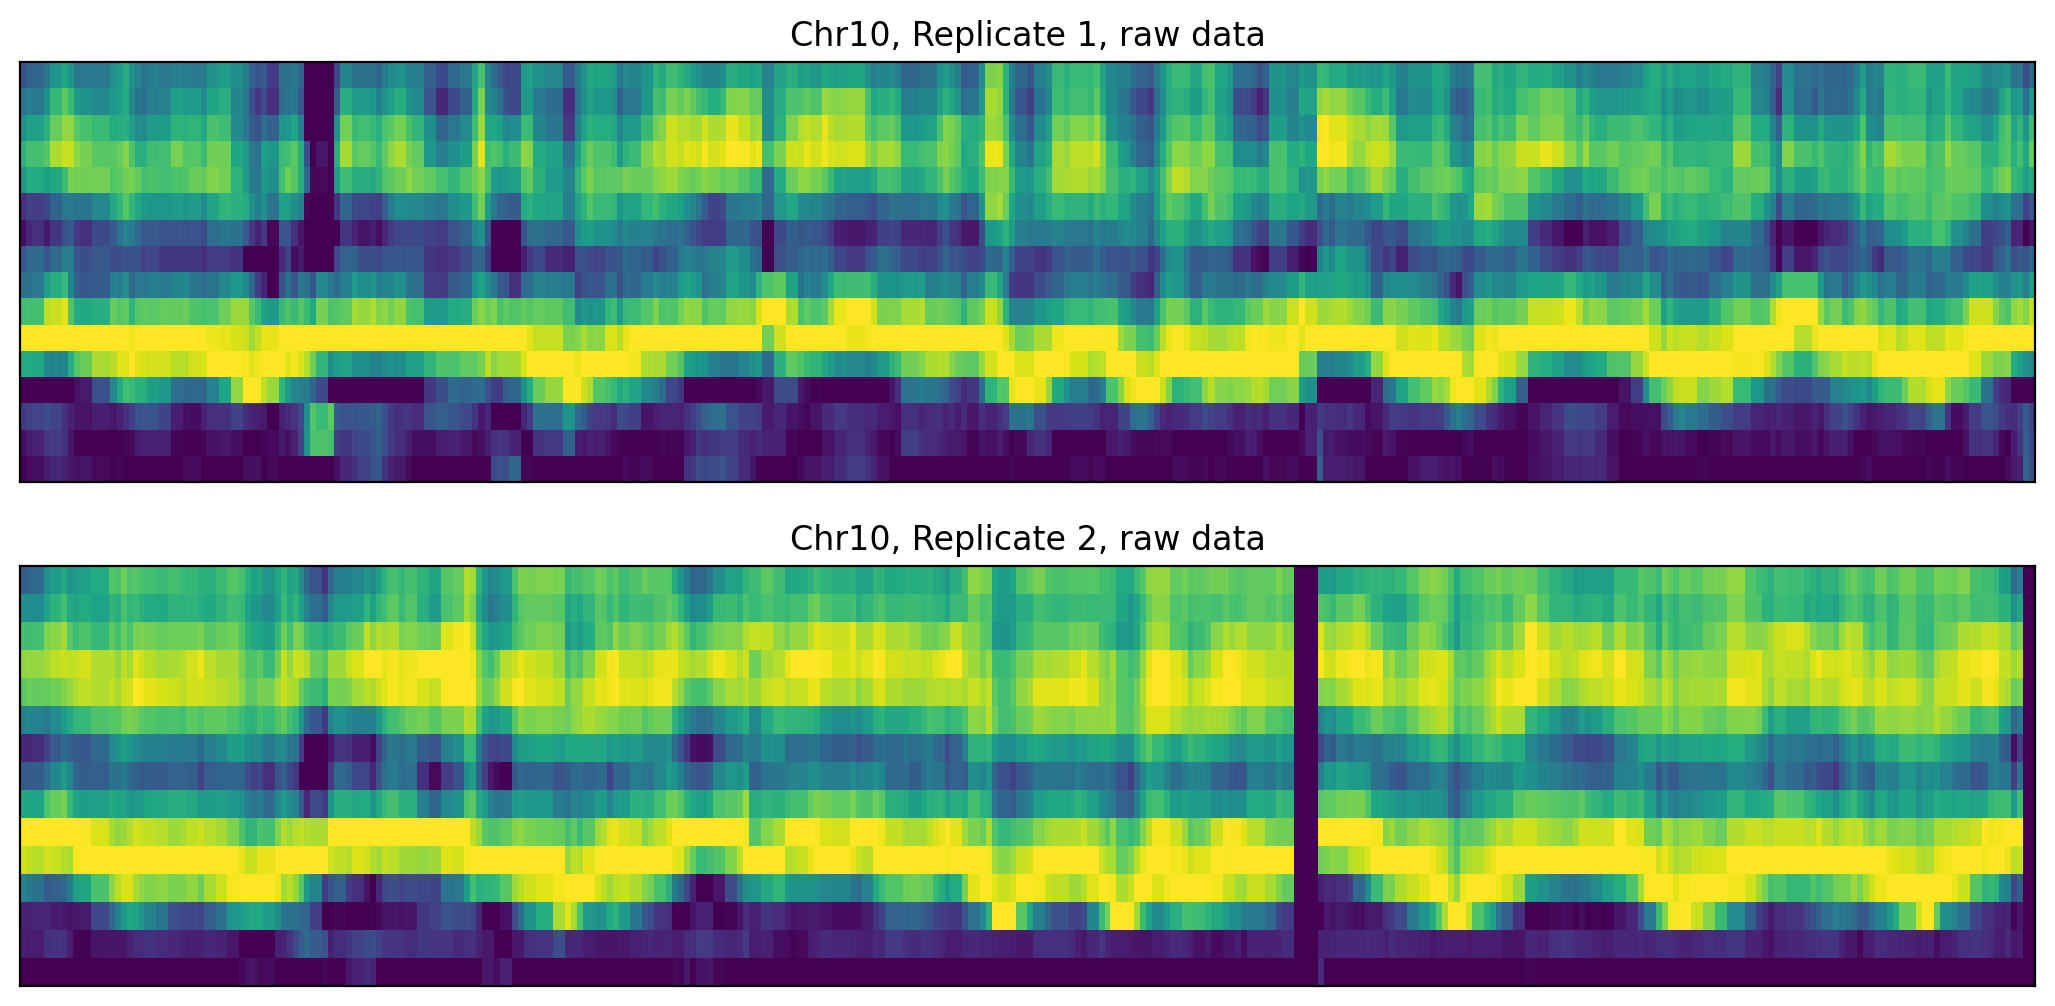

In [837]:
combined_repl_analysis.plot_raw_bin_curves()

In [862]:
from src.timer import Timer

timer = Timer()

# Iterate through all chromosomes, and deconvolve bin curves
for chrom in range(1, 17):
    
    print(f"Chromosome {chrom}", end="...")

    combined_repl_analysis.set_chromosome(chrom)
    combined_repl_analysis.deconvolve_bin_curves()
    combined_repl_analysis.compute_combined_replication_timing()

    save_dir = 'output/combined_deconv_repl_timing_results/'
    combined_repl_analysis.save_results(save_dir)

    print("Done.")
    timer.print_time()


Chromosome 1...Setting up bin curves for replicate 1, chromosome 1
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 1
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Deconvolving combined model with gamma=0.001, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 82)
Deconvolved in : 00:00:12.714
The fitting norm is 0.21, the smoothing norm is: 16.63
Saved output/combined_deconv_repl_timing_results//chr1_f.npy
Saved output/combined_deconv_repl_timing_results//chr1_repl.csv
00:00:28.148
Chromosome 2...Setting up bin curves for replicate 1, chromosome 2
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase read

Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 11
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Deconvolving combined model with gamma=0.001, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 308)
Deconvolved in : 00:00:50.066
The fitting norm is 0.14, the smoothing norm is: 16.65
Saved output/combined_deconv_repl_timing_results//chr11_f.npy
Saved output/combined_deconv_repl_timing_results//chr11_repl.csv
00:12:29.638
Chromosome 12...Setting up bin curves for replicate 1, chromosome 12
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 12
Setting up model with temporary gene. (Actual deconvoluti

In [866]:
# Load all the chromosome replication timings from disk and merge into a single csv file

all_repl_df = pd.DataFrame()

for chrom in range(1, 17):
    repl_df = pd.read_csv(f'output/combined_deconv_repl_timing_results/chr{chrom}_repl.csv').set_index('orf_name')
    all_repl_df = pd.concat([all_repl_df, repl_df])


In [888]:
repl_timing = (all_repl_df['tp_mother']+all_repl_df['tp_daughter'])/2.
all_repl_df['combined_repl'] = repl_timing
all_repl_df

,f_index_mother,tp_mother,f_index_daughter,tp_daughter,chr,combined_repl
orf_name,,,,,,
YAL067W-A,79,20.7524,79,20.7524,1,20.75240
YAL067C,79,20.7524,78,20.0700,1,20.41120
YAL064C-A,78,20.0700,77,19.3876,1,19.72880
YAL064W,73,16.6579,72,15.9754,1,16.31665
YAL063C-A,73,16.6579,72,15.9754,1,16.31665
...,...,...,...,...,...,...
YPR196W,57,5.7390,58,6.4214,16,6.08020
YPR198W,57,5.7390,58,6.4214,16,6.08020
YPR199C,56,5.0566,57,5.7390,16,5.39780


In [889]:
all_repl_df.to_csv('output/combined_deconv_repl_timing_results/all_repl.csv')

Text(0.5, 0, 'Replication timing, minutes')

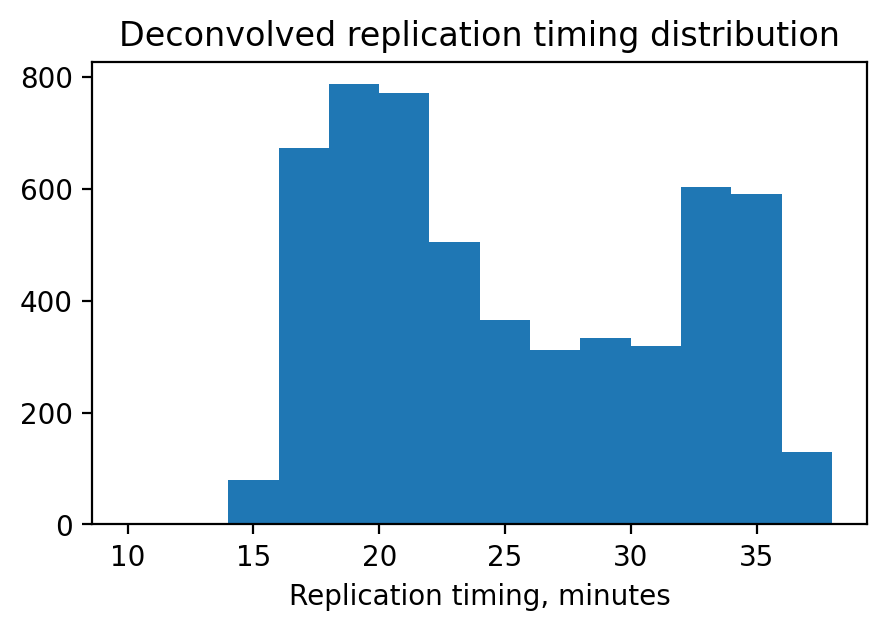

In [952]:
plt.figure(figsize=(5, 3))

plt.hist(all_repl_df.tp_mother + alpha, bins=np.arange(10, 40, 2.))
plt.title("Deconvolved replication timing distribution")
plt.xlabel("Replication timing, minutes")


In [989]:
from src.helpers import MakeONFilter, get_wavelet_kernel

#def get_wavelet_kernel(N, type="Symmlet", par=5):
#    return WavMat(MakeONFilter(type, par), N)

haar_wavelet = get_wavelet_kernel(32, 'Haar')
symmlet_wavelet = get_wavelet_kernel(32, 'Symmlet')


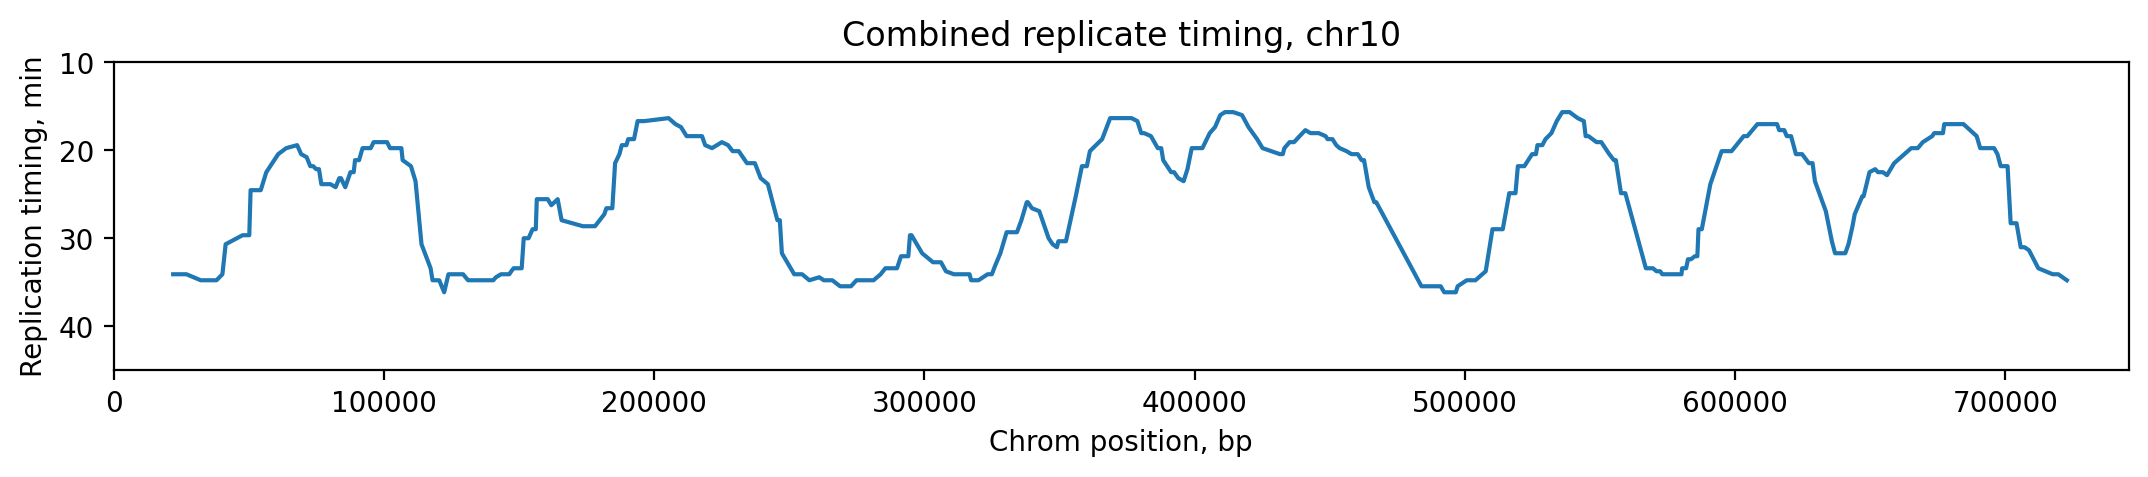

In [976]:
# Plot the replicating timing to match the profiles drawn by Brewer and Muller, 2014
plot_replication_timing_chr(all_repl_df, 10)

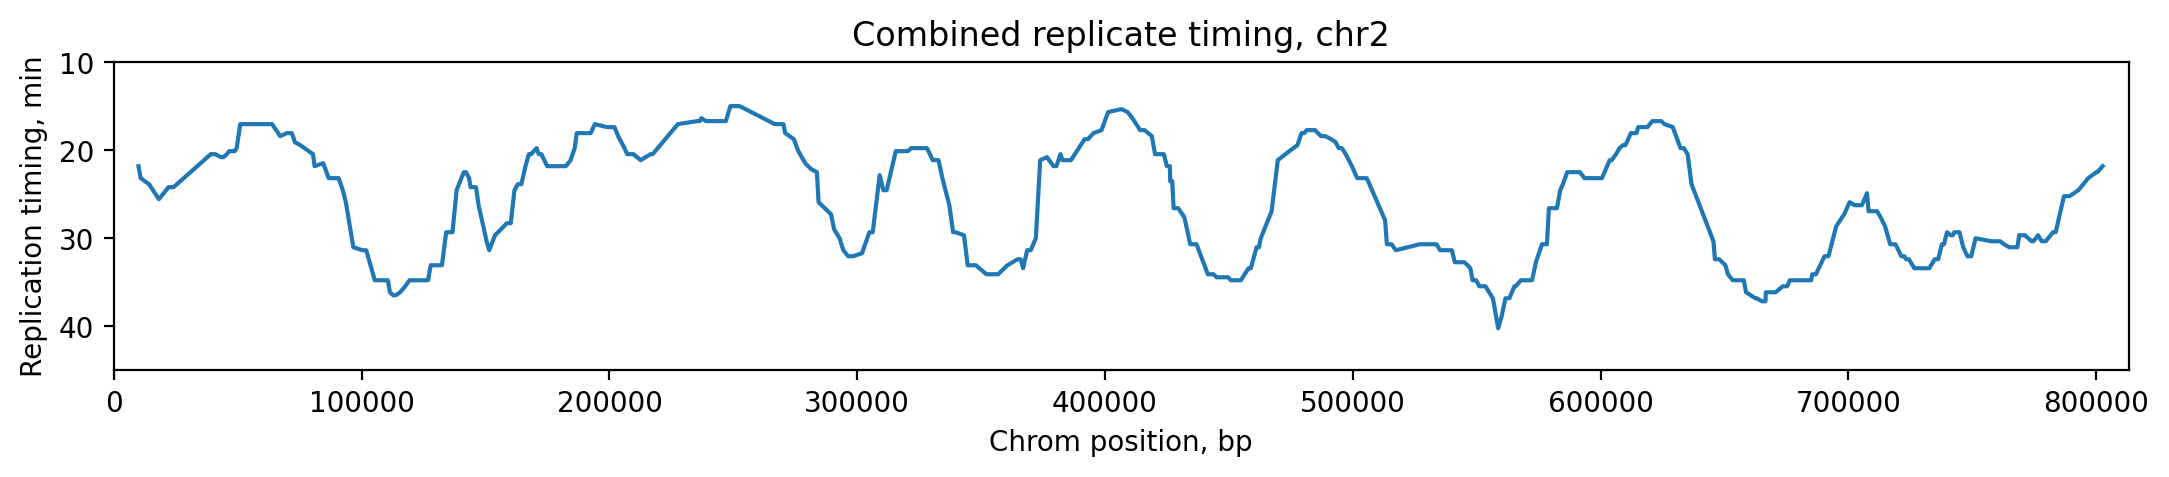

In [977]:
plot_replication_timing_chr(all_repl_df, 2)

In [ ]:
# Create the heatmap of the deconvolved data to see how the replicating timing
# looks on the heatmap data.
combined_repl_analysis.set_chromosome(10)
combined_repl_analysis.deconvolve_bin_curves()
combined_repl_analysis.compute_combined_replication_timing()

Setting up bin curves for replicate 1, chromosome 10
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 10
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Deconvolving combined model with gamma=0.001
Deconvolving bin size: 32x32
of G shape: (31, 334)


In [ ]:
combined_repl_analysis.compute_combined_replication_timing()

In [ ]:
combined_repl_analysis.plot_replication_heatmap()

In [ ]:
combined_repl_analysis.plot_replication_timing()